In [1]:
import kika
from kika.sensitivities import compute_sensitivity

In [8]:
mctal_file = r'c:\Users\Usuario\BaradDur\Dev\kika\files\mcnp-mctal\PWRSphere.m'
input_file = r'c:\Users\Usuario\BaradDur\Dev\kika\files\mcnp-input\PWRSpherePERT.i'

In [9]:
mctal = kika.read_mctal(mctal_file)
mcnp_input = kika.read_mcnp(input_file)

In [10]:
mcnp_input

                      MCNP Input Data                       

------------------------------------------------------------
                       PERTURBATIONS                        
------------------------------------------------------------
Number of perturbations:  1760
Perturbation IDs:         1-1760
Reactions available:      1, 2, 4, 51, 52, 102, 103, 107
Methods available:        -3, -2, 1, 2, 3
Perturbed materials:      300001
Energy range:             1.00e-11 - 2.00e+01 MeV
Energy bins:              44
Energy structure:         SCALE44

Use .perturbation to access perturbation data.

In [12]:
sens = compute_sensitivity(inputfile=input_file,mctalfile=mctal_file, tally=4, zaid=26056, label='Fe-56, det1')

sens

                             Sensitivity Data for Fe-56                              

Label:                           Fe-56, det1
Tally ID:                        4
Tally Name:                      shell Detector
Nuclide (ZAID):                  Fe-56 (26056)
Number of detector energy bins:  3
Number of perturbation bins:     44
Energy structure:                SCALE44
Reactions available:             1, 2, 4, 51, 52, 102, 103, 107
Second Order data available:     True

Energy group ranges:
  - 0.00e+00_1.00e-01
  - 1.00e-01_1.00e+00
  - 1.00e+00_3.00e+00
  - integral


Available Methods:
-------------------------------------------------------------------------------------
Method                                 Description                                 
-------------------------------------------------------------------------------------
.plot_sensitivity(...)                 Plot sensitivity profiles                   
.to_dataframe()                        Get full data as pandas

## Plot sensitivity profile

In [13]:
sens.data['integral'][51]

                              Sensitivity Coefficients                               

Energy: integral
Reaction Number (MT): 51
Number of perturbation bins: 44
Unperturbed result (R₀): 1.135840e-08 ± 0.5700% (relative)

Data preview (values and relative errors):

     Energy Bin     |      Value      |   Rel. Error
--------------------------------------------------
1.000e-11-3.000e-09 |    0.000000e+00 |     0.005700
3.000e-09-7.500e-09 |    0.000000e+00 |     0.005700
7.500e-09-1.000e-08 |    0.000000e+00 |     0.005700
...                                               
4.800e+00-6.434e+00 |    0.000000e+00 |     0.005700
6.434e+00-8.187e+00 |    0.000000e+00 |     0.005700
8.187e+00-2.000e+01 |    0.000000e+00 |     0.005700


Available Methods:
-------------------------------------------------------------------------------------
Method                      Description                                            
-----------------------------------------------------------------------

<Axes: title={'center': 'MT = 2'}, xlabel='Energy (MeV)', ylabel='Sensitivity per lethargy'>

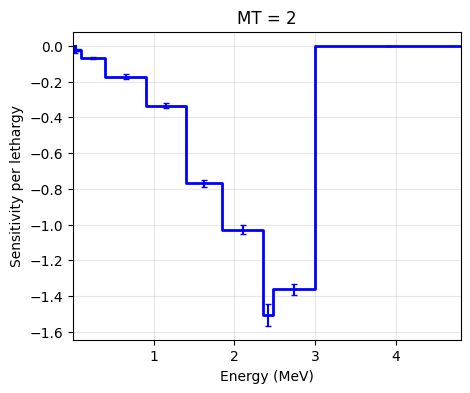

In [15]:
sens.data['integral'][2].plot(xlog=False)

<Axes: title={'center': 'MT = 2'}, xlabel='Energy (MeV)', ylabel='Sensitivity per lethargy'>

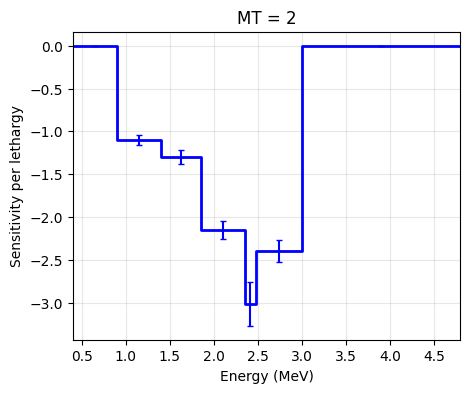

In [14]:
sens.data['1.00e+00_3.00e+00'][2].plot(xlog=False)

## Linearity analysis

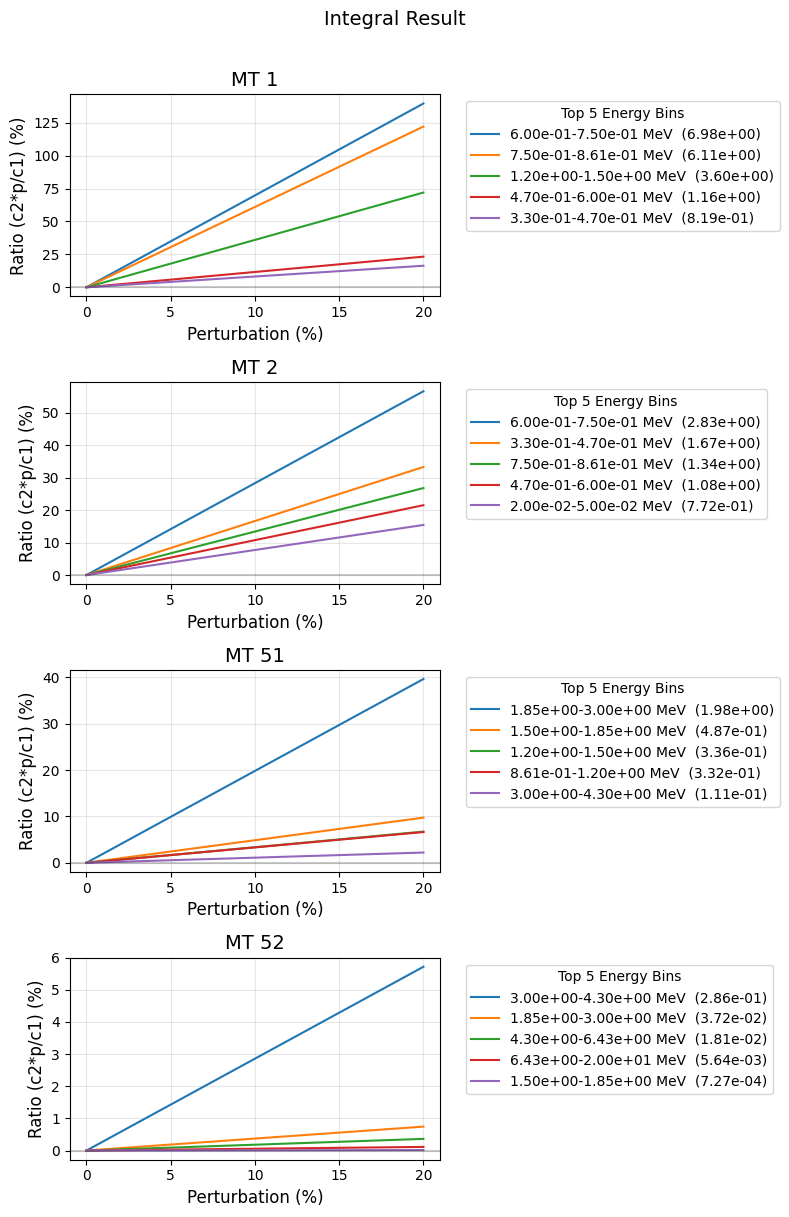

In [8]:
sens.plot_ratio()

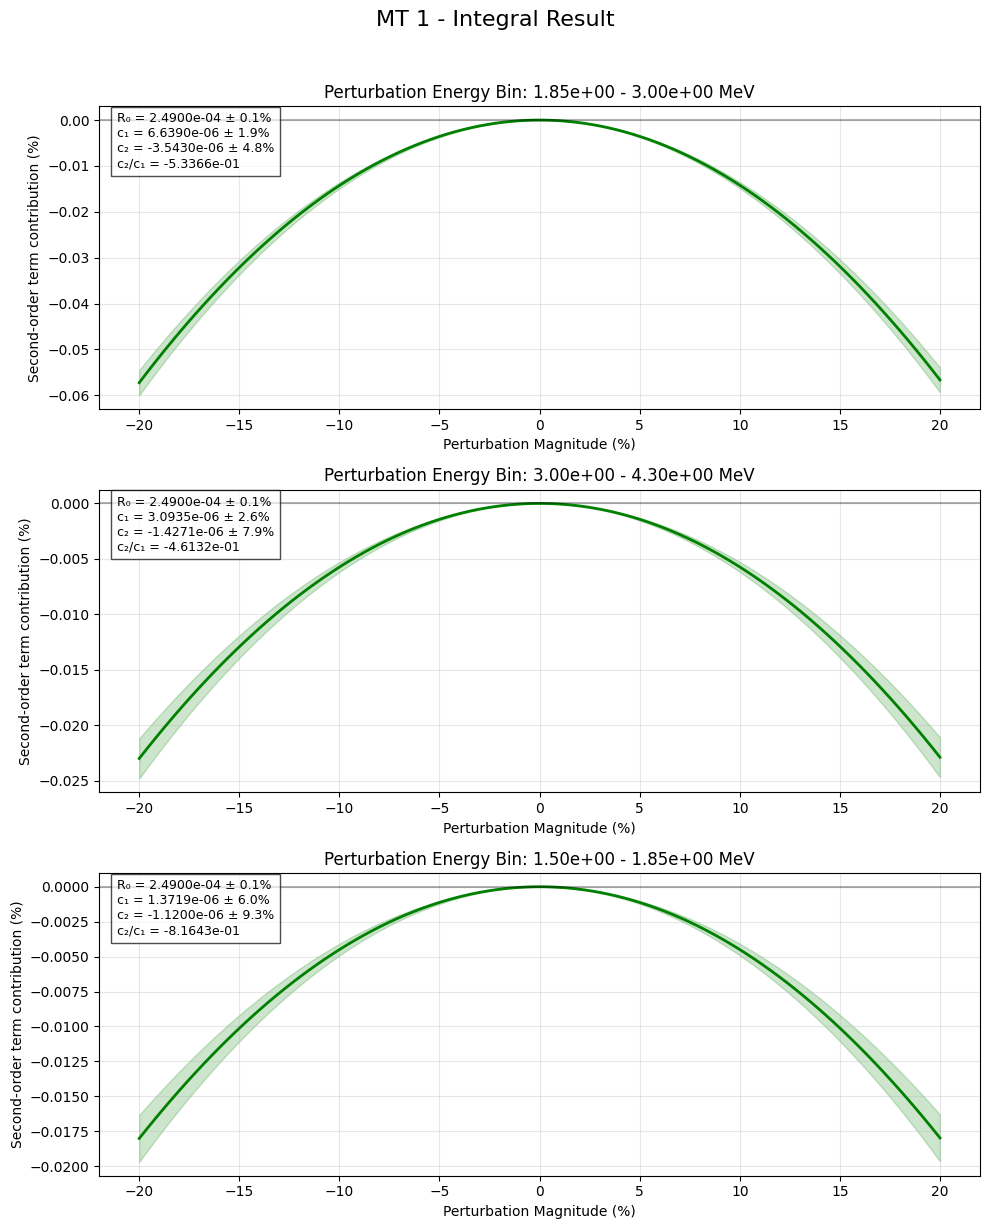

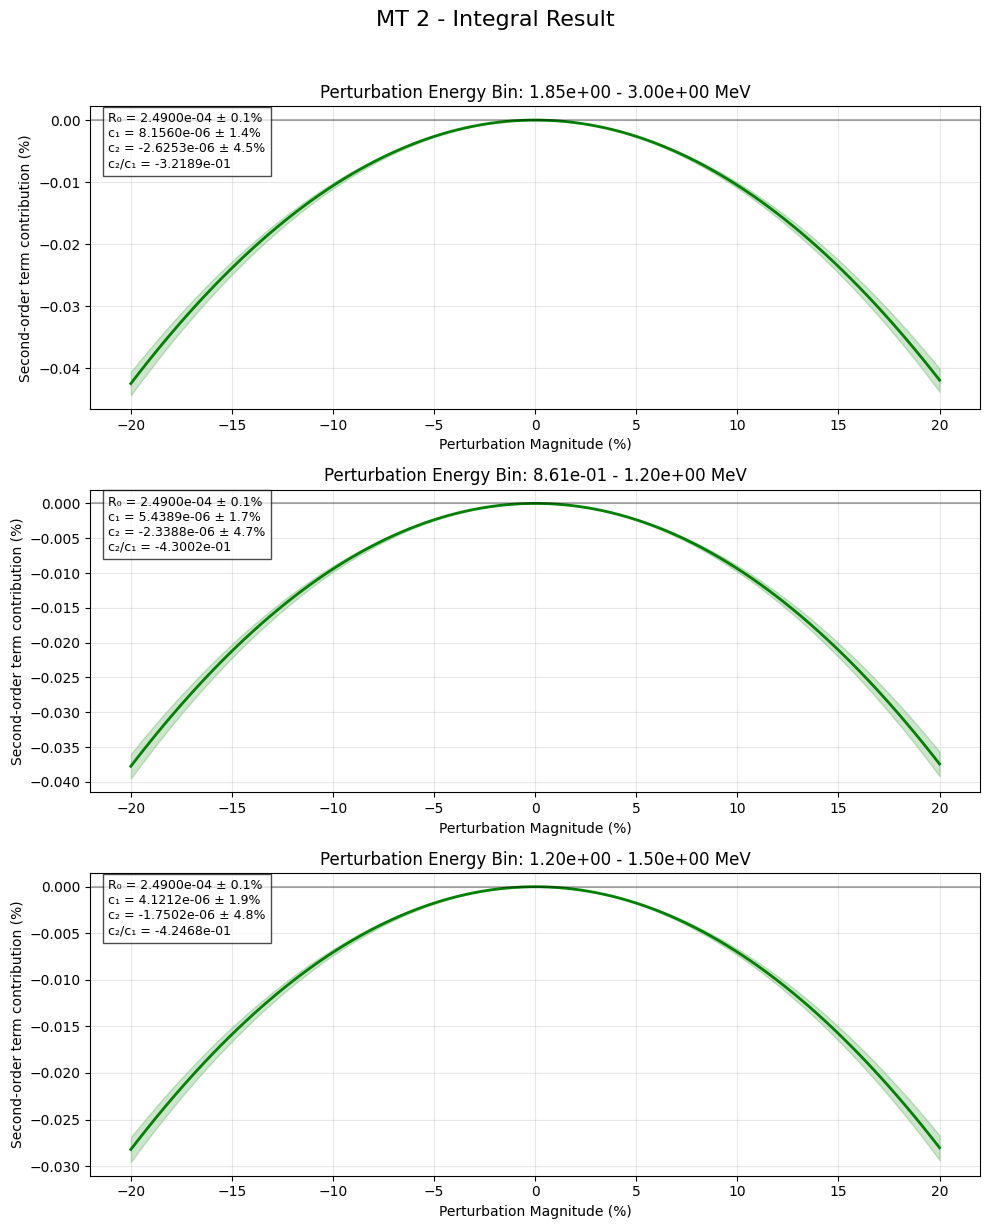

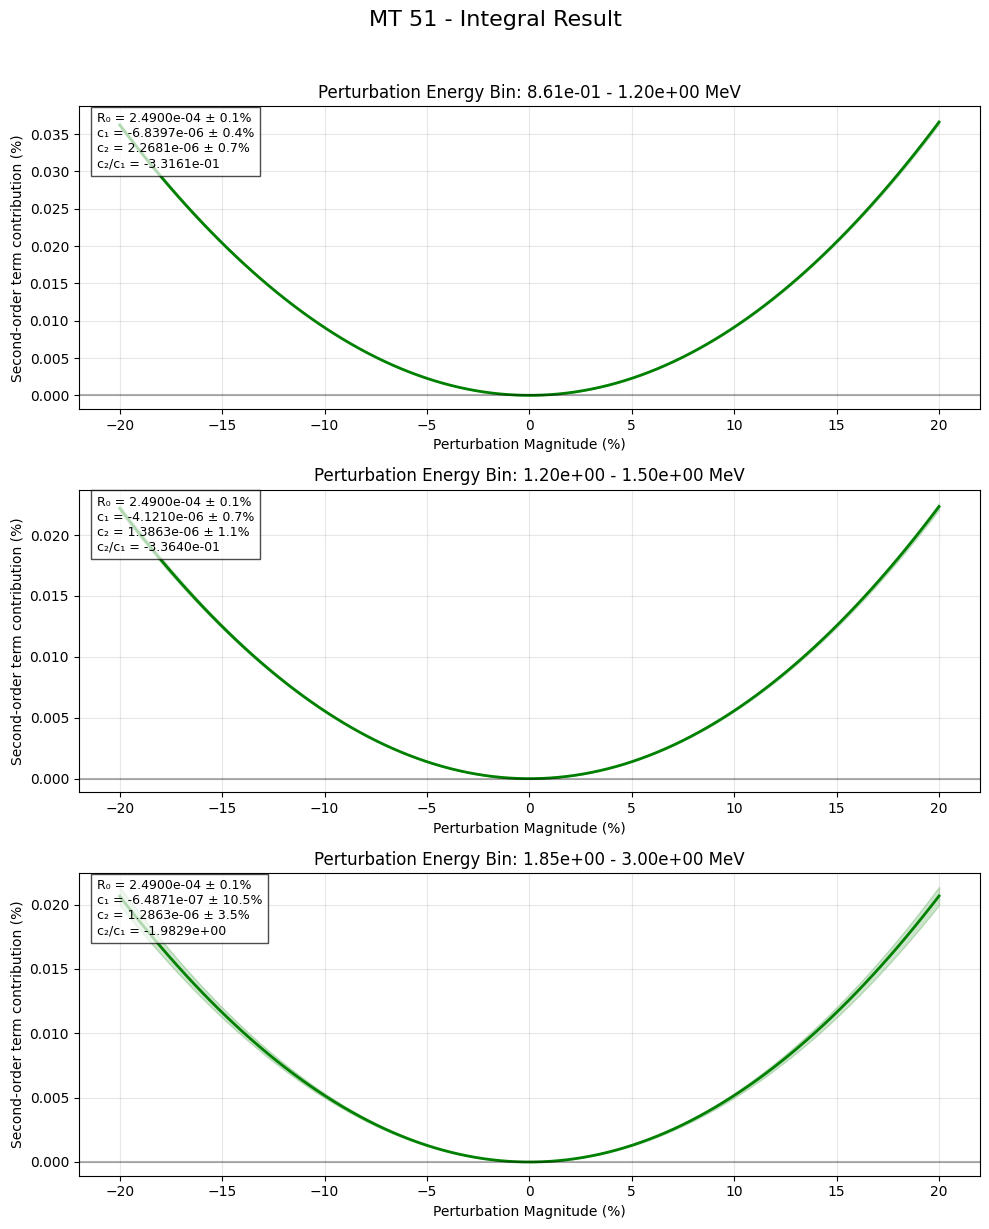

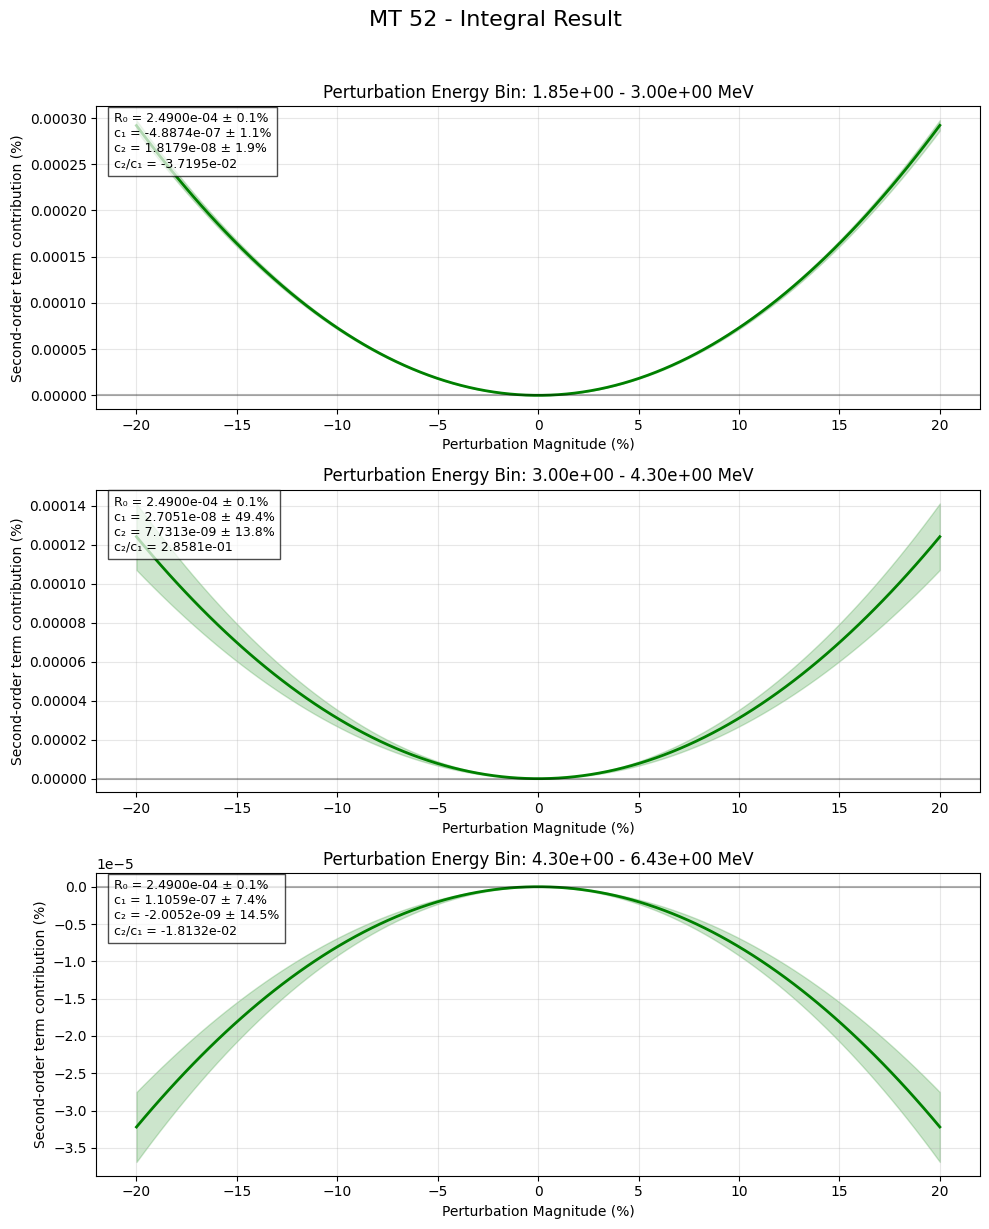

In [9]:
sens.plot_second_order_contribution()

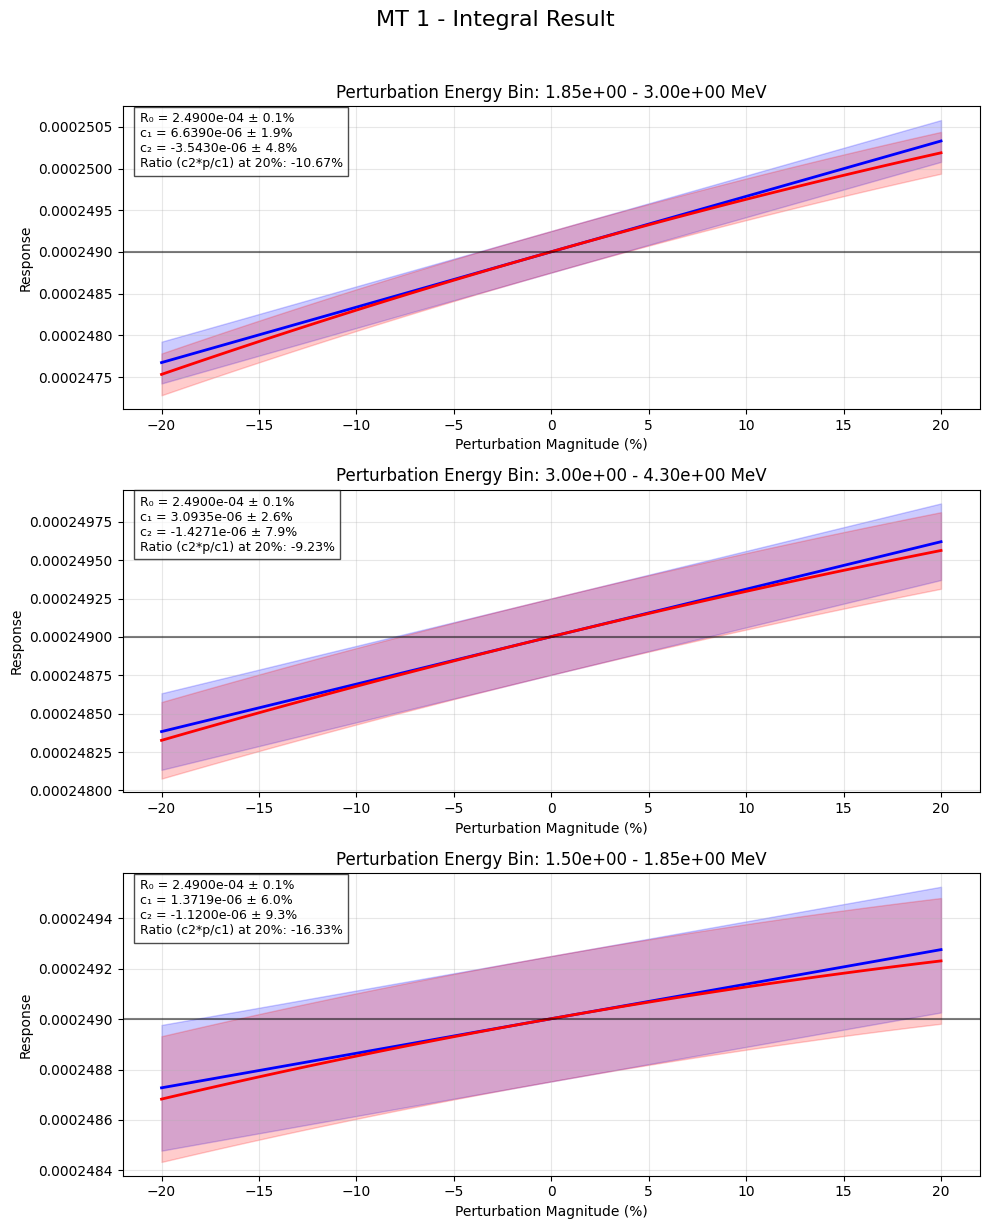

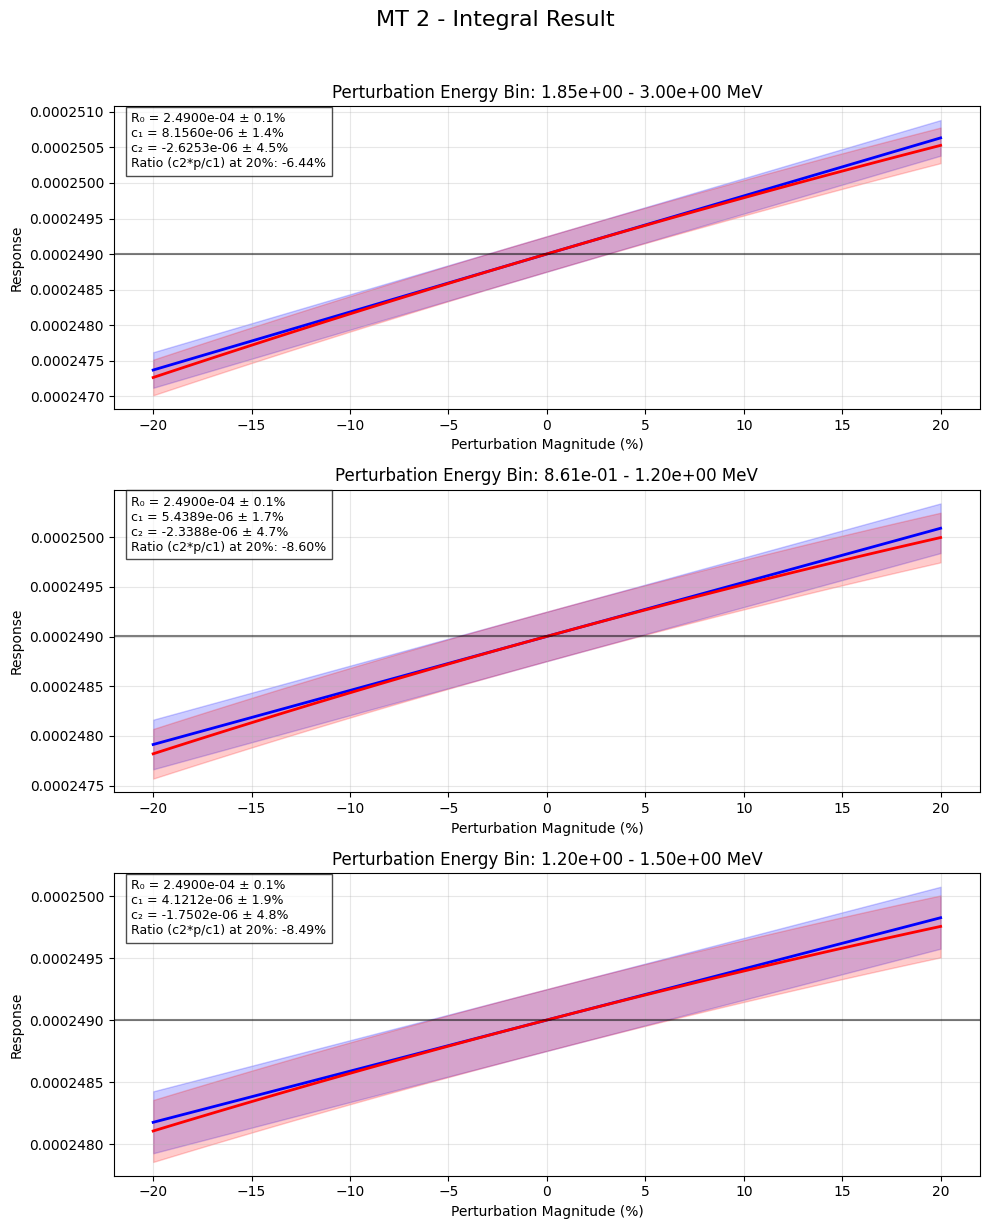

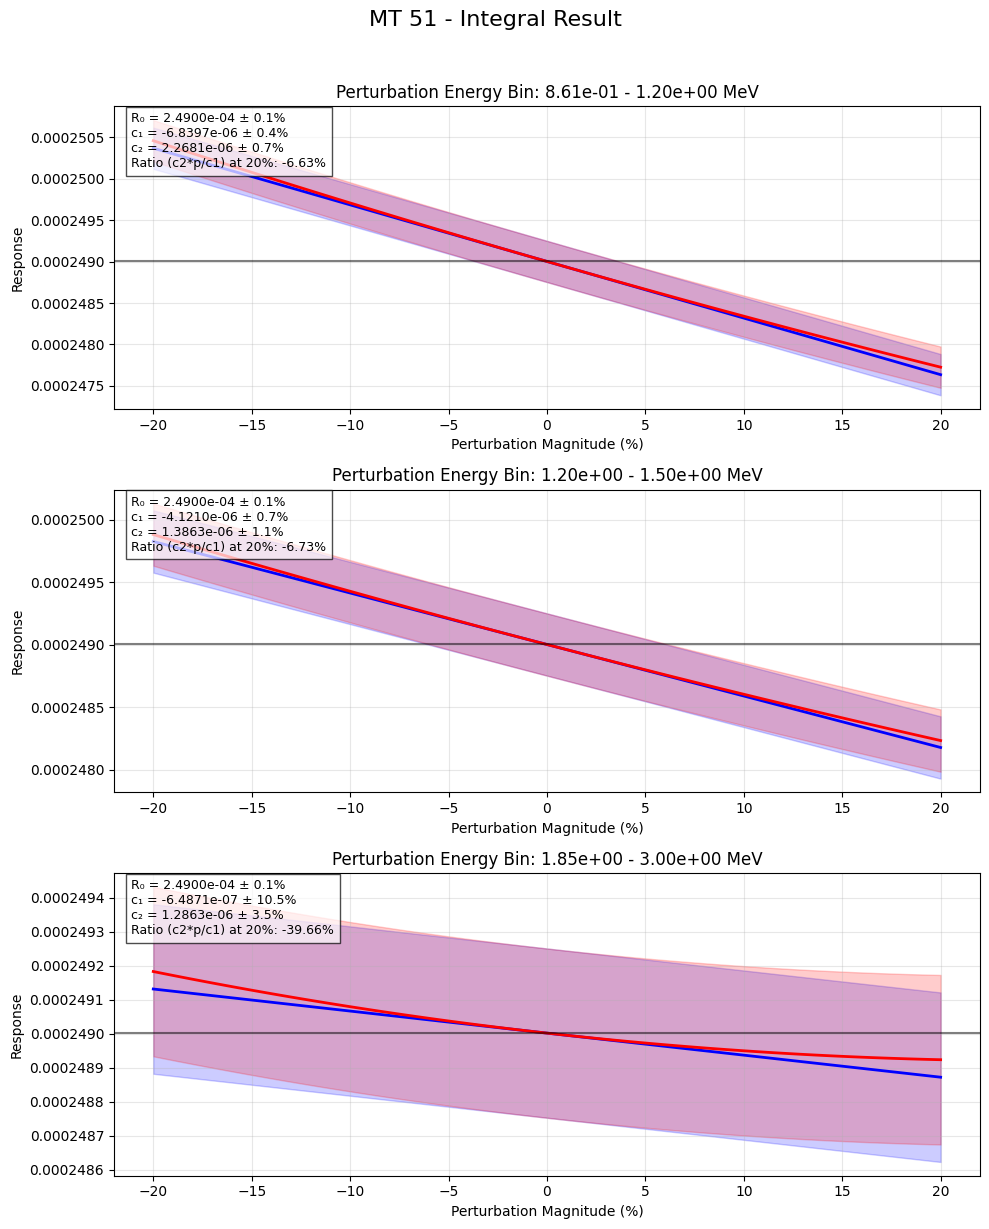

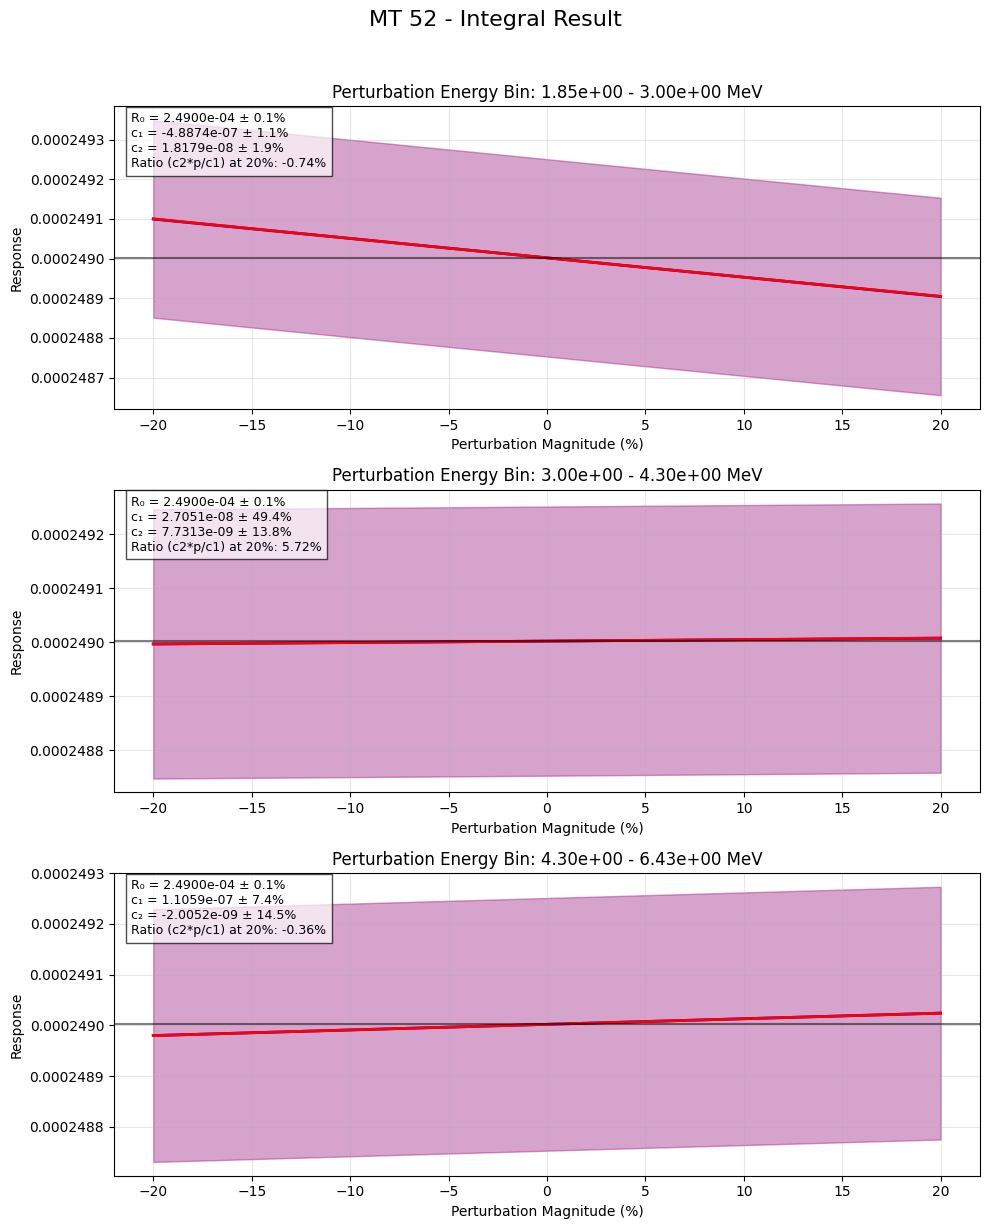

In [10]:
sens.plot_perturbed_response()